# Novel tandem repeats: what the screen found, and what it didn't

This notebook reads the two committed pipeline outputs and asks what they support.

| stage | file | what it holds |
|---|---|---|
| TRF calling | `first_500_INS.trf.tsv` | 4,518 tandem-repeat calls inside SV insertions |
| [novelty screen](../docs/tools/NOVELTY_SCREEN.md) | `first_500_INS.novelty.tsv` | the same calls, screened against UCSC `simpleRepeat` and TRExplorer |
| [STRchive comparison](../docs/tools/STRCHIVE_COMPARE.md) | `first_500_INS.strchive.tsv` | the filtered subset, compared against 82 known disease loci |

**Three findings, stated up front:**

1. **The purity filters remove the entire `novel_locus` category** — 0 of 621 rows survive. The most
   interesting class is exactly the one that gets cut, and for a defensible reason.
2. **The two reference catalogues disagree on 37% of calls.** A "novel" verdict is
   substantially a statement about which catalogue you asked.
3. **No candidate is near a known disease locus, and that was never in doubt.** STRchive
   covers 1 base in 251,338. The nearest approach in this sample is 8.3 kb.

This sample is the first 500 insertions of the SURVIVOR merge — a 3.5 Mb window of chr1.
It is a pipeline test, not a screen.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Run from anywhere: walk up to the repo root.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
DATA = ROOT / "data" / "sv_output" / "survivor_multi_sample_vcf"

novelty  = pd.read_csv(DATA / "first_500_INS.novelty.tsv",  sep="\t")
strchive = pd.read_csv(DATA / "first_500_INS.strchive.tsv", sep="\t")

print(f"novelty screen output : {len(novelty):,} rows x {novelty.shape[1]} cols")
print(f"STRchive output       : {len(strchive):,} rows x {strchive.shape[1]} cols")
print(f"catalogue             : {strchive.strchive_catalog.iloc[0]}")

novelty screen output : 4,518 rows x 41 cols
STRchive output       : 1,468 rows x 60 cols
catalogue             : STRchive v2.26.0 (hg38)


## Plot style

Colours come from a validated categorical palette: three slots, assigned in fixed order to the
three novelty classes and never reused for anything else. The aqua slot sits below 3:1 contrast
on this surface, so every chart carries direct value labels and prints its underlying table —
identity is never left to colour alone.

In [2]:
# --- validated palette (light surface) ---------------------------------------
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_2     = "#52514e"
MUTED     = "#898781"
GRID      = "#e1e0d9"
AXIS      = "#c3c2b7"

# Categorical slots 1-3, in fixed order. One class, one colour, everywhere.
CLASSES = ["known", "novel_motif", "novel_locus"]
CLASS_COLOR = {"known": "#2a78d6", "novel_motif": "#eb6834", "novel_locus": "#1baf7a"}

# Sequential ramp (one hue, light -> dark) for magnitude-only encodings.
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
SEQ_CMAP = mpl.colors.LinearSegmentedColormap.from_list("seq_blue", SEQ)

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 140, "font.size": 9.5,
    "font.family": "sans-serif",
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",  # hairline, solid
    "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2, "lines.markersize": 8,
})

def titled(ax, title, subtitle=None):
    '''Left-aligned title with an optional quieter subtitle, in ink tokens.'''
    ax.set_title(title, loc="left", fontsize=11, fontweight="semibold", pad=22 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.035, subtitle, transform=ax.transAxes, fontsize=9, color=INK_2, va="bottom")
    return ax

## 1. Rows are not loci

Every count in this pipeline has two denominators. A row is one TRF call — locus x sample x call —
so a locus recurrent across 20 samples contributes 20 rows. **Per-row percentages track recurrence
more than they track novelty**, so both are reported throughout.

In [3]:
LOCUS_KEY = ["chrom", "ins_coord"]

def per_locus(frame):
    '''Collapse rows to loci. A locus is only as novel as its least-novel call.'''
    rank = {"known": 0, "novel_motif": 1, "novel_locus": 2}
    return (frame.assign(_r=frame.novelty.map(rank))
                 .groupby(LOCUS_KEY)._r.min()
                 .map({v: k for k, v in rank.items()}))

rows_by_class  = novelty.novelty.value_counts().reindex(CLASSES)
loci_by_class  = per_locus(novelty).value_counts().reindex(CLASSES)

summary = pd.DataFrame({"rows": rows_by_class, "loci": loci_by_class})
summary["rows %"] = (summary["rows"] / summary["rows"].sum() * 100).round(1)
summary["loci %"] = (summary["loci"] / summary["loci"].sum() * 100).round(1)
summary

,rows,loci,rows %,loci %
known,2318,114,51.3,51.6
novel_motif,1579,81,34.9,36.7
novel_locus,621,26,13.7,11.8


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


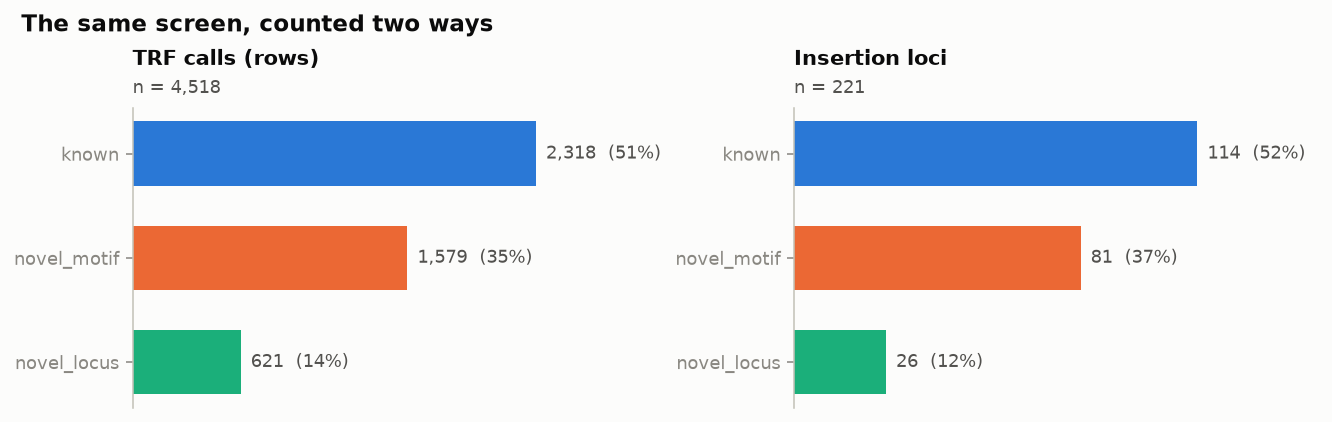

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 2.9), constrained_layout=True)
for ax, col, label in zip(axes, ["rows", "loci"], ["TRF calls (rows)", "Insertion loci"]):
    vals = summary[col]
    ax.barh(CLASSES[::-1], vals[CLASSES[::-1]], height=0.62,
            color=[CLASS_COLOR[c] for c in CLASSES[::-1]])
    for i, c in enumerate(CLASSES[::-1]):
        # Direct label outside the bar end: the relief rule, and it keeps the axis quiet.
        ax.text(vals[c] + vals.max() * 0.025, i, f"{vals[c]:,}  ({summary.loc[c, col + ' %']:.0f}%)",
                va="center", fontsize=9, color=INK_2)
    ax.set_xlim(0, vals.max() * 1.30)
    ax.set_xticks([])
    ax.grid(False)
    ax.spines["bottom"].set_visible(False)
    titled(ax, label, f"n = {vals.sum():,}")
fig.suptitle("The same screen, counted two ways", x=0.01, ha="left",
             fontsize=12, fontweight="semibold", color=INK)
plt.show()

`novel_motif` is the largest novel class either way — but the novelty screen's own docs flag two
reasons it over-calls (near-miss motifs, and sub-repeat containment that the matching rule does not
yet test). Treat 81 novel-motif loci as an upper bound.

One thing this run **cannot** tell you: how many are near misses. The screen ran with
`--max-motif-edits 0`, and it caps the reported edit distance at `max_motif_edits + 1`. So every
non-matching motif reports `1`, meaning "did not match exactly" — *not* "one substitution away".
Answering that needs a re-run at `--max-motif-edits 1`.

In [5]:
# The cap, made visible -- so nobody reads `1` as `one edit`.
novelty.ucsc_motif_edits.value_counts(dropna=False).rename("rows").to_frame().T

ucsc_motif_edits,1.0,0.0,NaN
rows,2919,852,747


## 2. The purity filters delete the `novel_locus` class

The STRchive step consumes the *filtered* table: calls with TRF purity >= 0.8 that sit in an
insertion which is >= 80% tandem repeat overall. That second threshold is not neutral across classes.

In [6]:
MIN_PURITY = MIN_INSERTION_PURITY = 0.8
novelty["passes"] = ((novelty.purity >= MIN_PURITY)
                     & (novelty.insertion_purity >= MIN_INSERTION_PURITY))

fate = pd.crosstab(novelty.novelty, novelty.passes).reindex(CLASSES)
fate.columns = ["filtered out", "kept"]
fate["pass rate"] = (fate["kept"] / fate.sum(axis=1) * 100).round(1)
fate["median insertion_purity"] = novelty.groupby("novelty").insertion_purity.median().round(3)
fate

,filtered out,kept,pass rate,median insertion_purity
novelty,,,,
known,1395,923,39.8,0.701
novel_motif,1034,545,34.5,0.834
novel_locus,621,0,0.0,0.055


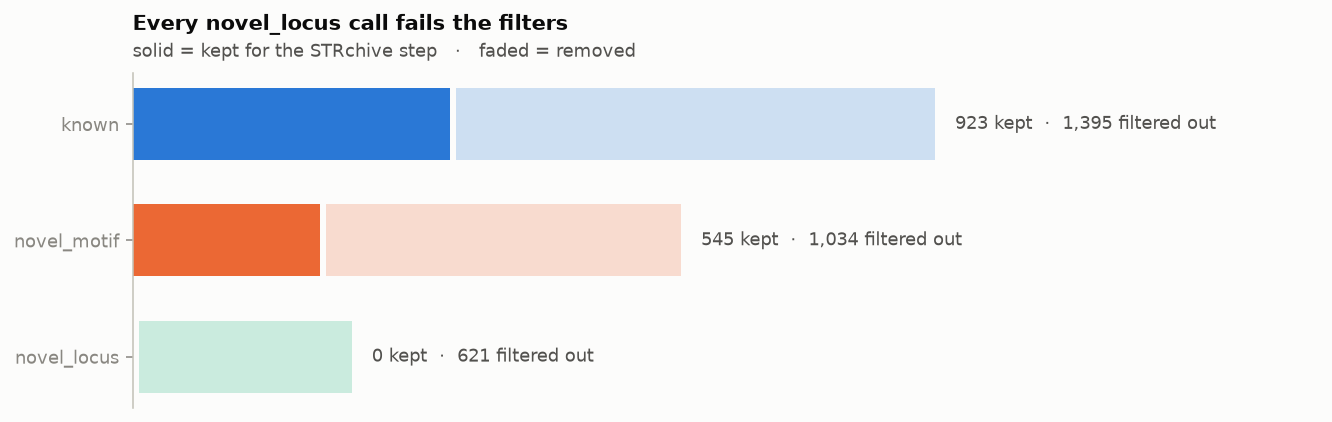

In [7]:
fig, ax = plt.subplots(figsize=(9.4, 2.9), constrained_layout=True)
y = np.arange(len(CLASSES))[::-1]
for i, cls in zip(y, CLASSES):
    kept, cut = fate.loc[cls, "kept"], fate.loc[cls, "filtered out"]
    # 2px surface gap between adjacent fills, not a border.
    ax.barh(i, kept, height=0.62, color=CLASS_COLOR[cls])
    ax.barh(i, cut, left=kept + 18, height=0.62, color=CLASS_COLOR[cls], alpha=0.22)
    ax.text(kept + cut + 75, i, f"{kept:,} kept  ·  {cut:,} filtered out",
            va="center", fontsize=9, color=INK_2)
ax.set_yticks(y, CLASSES)
ax.set_xlim(0, 3450)
ax.set_xticks([]); ax.grid(False); ax.spines["bottom"].set_visible(False)
titled(ax, "Every novel_locus call fails the filters",
       "solid = kept for the STRchive step   ·   faded = removed")
plt.show()

Not a rounding artefact — **0 of 621**. The reason is in the distribution below: repeats at loci the
reference annotates *nothing* near sit inside insertions that are overwhelmingly not tandem repeat
(median insertion purity 0.055, against 0.70 and 0.83 for the other two classes).

Both readings are defensible, and they point in opposite directions:

- **The filter is working.** A 40 bp repeat inside a 3 kb insertion of unique sequence is not a
  tandem-repeat expansion; it is a repeat that happens to be along for the ride.
- **The filter forecloses the question.** Any analysis downstream of this threshold can never
  observe a novel locus, because none reaches it. If novel loci are the point of the project, this
  threshold — not the screen — is what decides the answer.

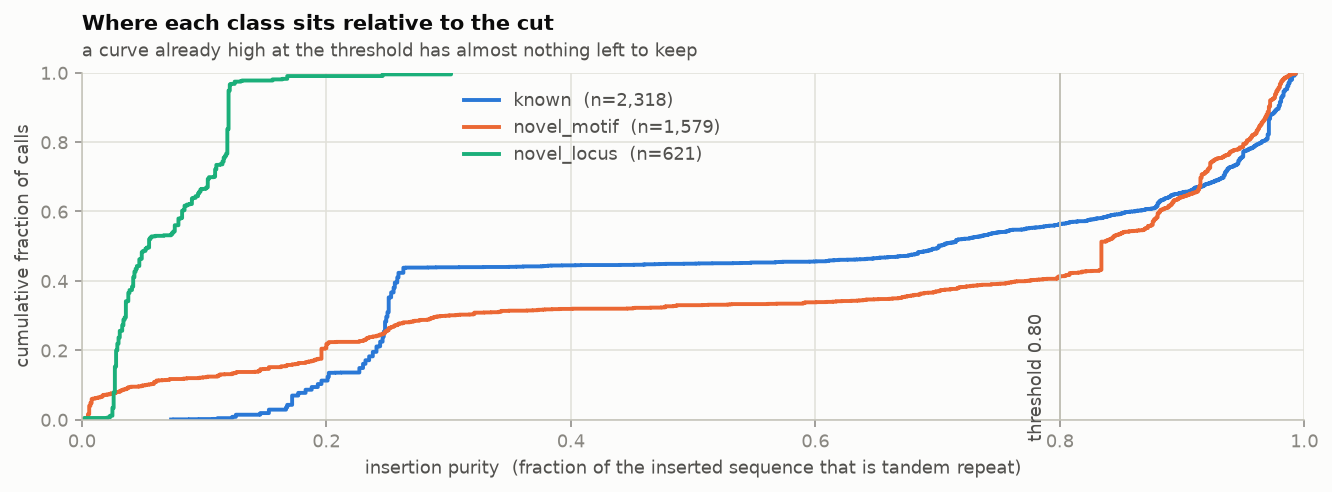

In [8]:
fig, ax = plt.subplots(figsize=(9.4, 3.4), constrained_layout=True)
for cls in CLASSES:                       # fixed order, so colour never shifts
    v = np.sort(novelty.loc[novelty.novelty == cls, "insertion_purity"].to_numpy())
    ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post",
            color=CLASS_COLOR[cls], label=f"{cls}  (n={len(v):,})")
ax.axvline(MIN_INSERTION_PURITY, color=AXIS, lw=1)
ax.text(MIN_INSERTION_PURITY - 0.012, 0.12, "threshold 0.80", rotation=90,
        ha="right", va="center", fontsize=9, color=INK_2)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("insertion purity  (fraction of the inserted sequence that is tandem repeat)")
ax.set_ylabel("cumulative fraction of calls")
ax.legend(loc="upper left", bbox_to_anchor=(0.30, 0.99), fontsize=9, labelcolor=INK_2)
titled(ax, "Where each class sits relative to the cut",
       "a curve already high at the threshold has almost nothing left to keep")
plt.show()

By the threshold, ~95% of `novel_locus` calls are already accounted for — the curve is nearly flat
by 0.1. The other two classes still have most of their mass to the right of the line.

## 3. "Novel" depends on which catalogue you ask

The screen was run against two reference catalogues. They are not interchangeable.

In [9]:
matrix = pd.crosstab(novelty.ucsc_novelty, novelty.trexplorer_novelty).reindex(
    index=CLASSES, columns=CLASSES).fillna(0).astype(int)
agree = int(np.trace(matrix.to_numpy()))
print(f"agree on {agree:,} of {len(novelty):,} rows  ({agree / len(novelty):.1%})")
matrix

agree on 2,835 of 4,518 rows  (62.7%)


trexplorer_novelty,known,novel_motif,novel_locus
ucsc_novelty,,,
known,809,32,11
novel_motif,1437,1405,77
novel_locus,29,97,621


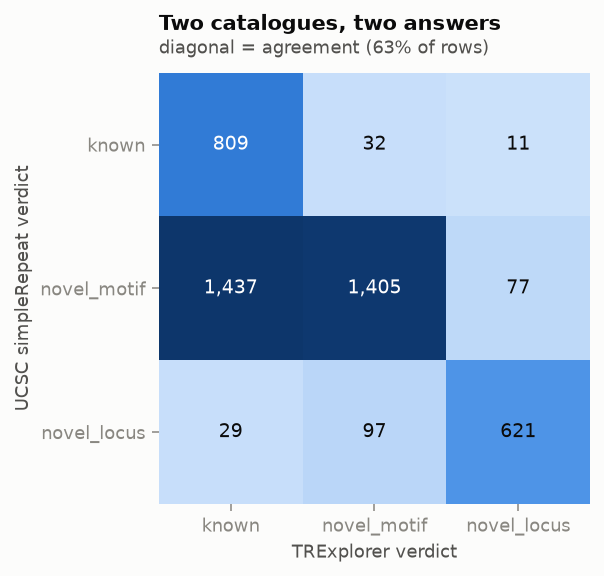

In [10]:
fig, ax = plt.subplots(figsize=(6.6, 4.0), constrained_layout=True)
m = matrix.to_numpy()
im = ax.imshow(m, cmap=SEQ_CMAP, vmin=0, vmax=m.max())      # sequential: magnitude only
ax.set_xticks(range(3), CLASSES, fontsize=9)
ax.set_yticks(range(3), CLASSES, fontsize=9)
ax.set_xlabel("TRExplorer verdict"); ax.set_ylabel("UCSC simpleRepeat verdict")
ax.grid(False)
for i in range(3):
    for j in range(3):
        # Value on every cell is right here: a matrix IS the table view.
        ax.text(j, i, f"{m[i, j]:,}", ha="center", va="center", fontsize=10,
                color="white" if m[i, j] > m.max() * 0.55 else INK)
for s in ax.spines.values():
    s.set_visible(False)
titled(ax, "Two catalogues, two answers",
       f"diagonal = agreement ({agree / len(novelty):.0%} of rows)")
plt.show()

The off-diagonal is the story. **1,428 calls that UCSC flags as `novel_motif`, TRExplorer already
knows** — TRExplorer is the larger catalogue (5.6M entries against 1.05M), and it absorbs most of
UCSC's motif-novelty calls.

The two agree almost perfectly on `novel_locus` (621 of 621 that UCSC calls novel_locus, TRExplorer
does too). That is the reassuring half: when *neither* catalogue annotates anything at a position,
that is a property of the position, not of the catalogue. It is also the class the filters delete.

## 4. Nothing is near a known disease locus

STRchive curates 82 pathogenic TR loci. Against a 3.1 Gb genome that is a very small target.

In [11]:
from strchive.catalog import Catalog

catalog = Catalog.load(verbose=False)
covered = sum(locus.length for locus in catalog)
print(f"{len(catalog)} disease loci spanning {covered:,} bp")
print(f"= {covered / 3.1e9:.2e} of a 3.1 Gb genome, or 1 base in {3.1e9 / covered:,.0f}")
print()
print(strchive.strchive_status.value_counts().rename("rows").to_frame())

82 disease loci spanning 12,334 bp
= 3.98e-06 of a 3.1 Gb genome, or 1 base in 251,338

                 rows
strchive_status      
no_locus_match   1468


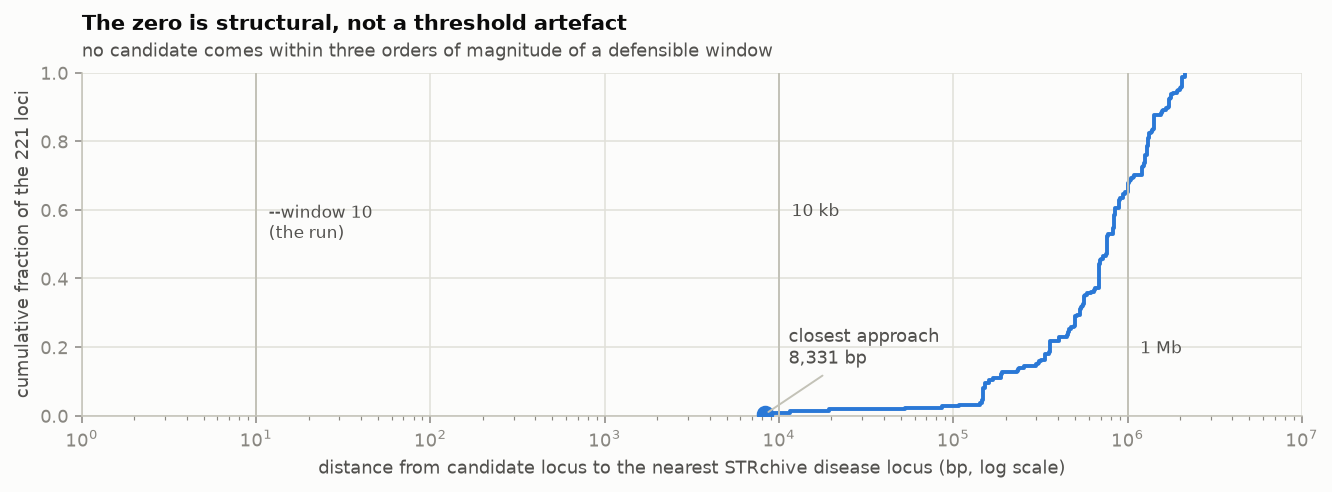

In [12]:
# How far is each candidate locus from the nearest disease locus?
loci = novelty[LOCUS_KEY].drop_duplicates()
distances = np.array([
    catalog.nearby(c, p - 1, p, window=300_000_000)[0].distance_to(p - 1, p)
    for c, p in loci.itertuples(index=False)
])

fig, ax = plt.subplots(figsize=(9.4, 3.4), constrained_layout=True)
v = np.sort(distances)
ax.step(v, np.arange(1, len(v) + 1) / len(v), where="post", color="#2a78d6")
# The curve is monotone, so each label goes on whichever side of it is empty.
for bp, label, y in [(10, "--window 10\n(the run)", 0.62), (10_000, "10 kb", 0.62),
                     (1_000_000, "1 Mb", 0.22)]:
    ax.axvline(bp, color=AXIS, lw=1)
    ax.text(bp * 1.18, y, label, fontsize=8.5, color=INK_2, va="top")
ax.scatter([v[0]], [1 / len(v)], color="#2a78d6", zorder=3)
ax.annotate(f"closest approach\n{v[0]:,} bp", (v[0], 1 / len(v)), textcoords="offset points",
            xytext=(12, 26), fontsize=9, color=INK_2,
            arrowprops=dict(arrowstyle="-", color=AXIS, lw=1))
ax.set_xscale("log"); ax.set_xlim(1, 1e7); ax.set_ylim(0, 1)
ax.set_xlabel("distance from candidate locus to the nearest STRchive disease locus (bp, log scale)")
ax.set_ylabel("cumulative fraction of the 221 loci")
titled(ax, "The zero is structural, not a threshold artefact",
       "no candidate comes within three orders of magnitude of a defensible window")
plt.show()

In [13]:
pd.DataFrame(
    [(w, int((distances <= w).sum())) for w in (10, 100, 1_000, 10_000, 100_000, 1_000_000)],
    columns=["--window (bp)", "loci that would match"],
).set_index("--window (bp)")

,loci that would match
--window (bp),
10,0
100,0
1000,0
10000,2
100000,6
1000000,144


Widening the window does not rescue the result: it takes **1 Mb** before most loci "match", and a
1 Mb window is not a locus match, it is a chromosome-arm match.

The sample spans chr1:121,069–3,583,350. Exactly one STRchive locus lies inside that window
(`HMNR7_VWA1`), and the nearest candidate insertion is 8,331 bp from it.

**This is the expected result for a 3.5 Mb slice, and it is worth stating plainly rather than
dressing up.** The STRchive step is verified — driven with synthetic calls at real disease
coordinates it separates a pathogenic RFC1 `AAGGG` expansion from a benign reference `AAAAG`
expansion of identical length — but this input has nothing for it to find.

## 5. What these repeats actually are

The motifs that survive filtering, by how many distinct loci carry them.

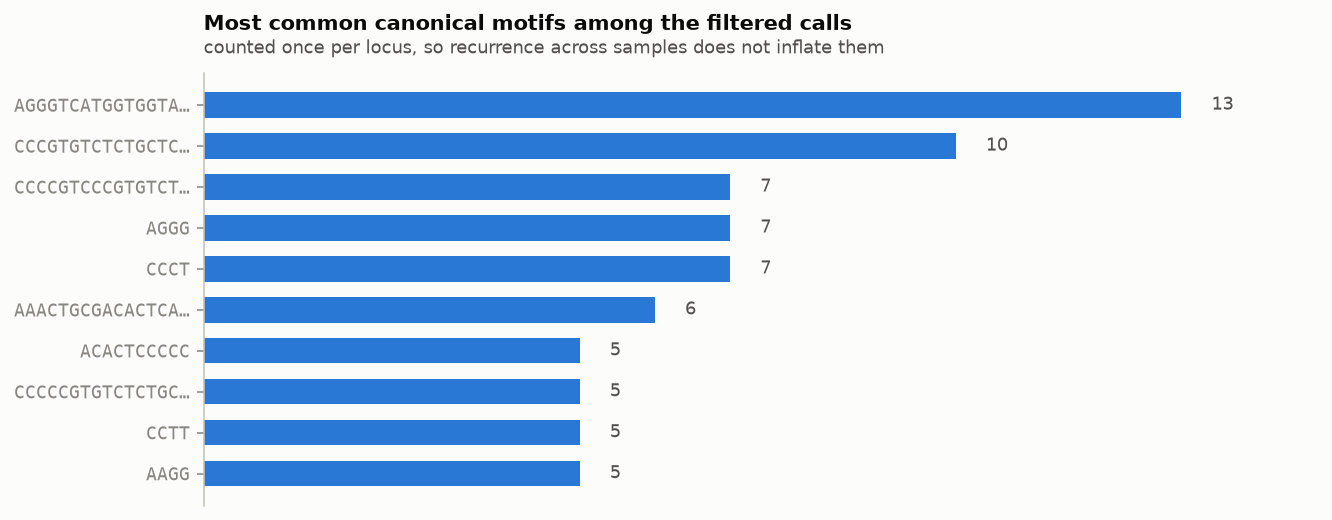

,loci
canonical_motif,
AGGGTCATGGTGGTAGTT,13
CCCGTGTCTCTGCTCCGT,10
CCCCGTCCCGTGTCTCTG,7
AGGG,7
CCCT,7
AAACTGCGACACTCACGCGGGTGCCGTCTCAGCAGCTCACGGTGTGG,6
ACACTCCCCC,5
CCCCCGTGTCTCTGCCCCGT,5
CCTT,5


In [14]:
top = (strchive.drop_duplicates(LOCUS_KEY + ["canonical_motif"])
               .canonical_motif.value_counts().head(10))
short = [m if len(m) <= 16 else m[:15] + "…" for m in top.index]

fig, ax = plt.subplots(figsize=(9.4, 3.6), constrained_layout=True)
ax.barh(range(len(top))[::-1], top.to_numpy(), height=0.62, color="#2a78d6")
for i, v in zip(range(len(top))[::-1], top.to_numpy()):
    ax.text(v + 0.4, i, str(v), va="center", fontsize=9, color=INK_2)
ax.set_yticks(range(len(top))[::-1], short, fontfamily="monospace", fontsize=9)
ax.set_xlim(0, top.max() * 1.14)
ax.set_xticks([]); ax.grid(False); ax.spines["bottom"].set_visible(False)
titled(ax, "Most common canonical motifs among the filtered calls",
       "counted once per locus, so recurrence across samples does not inflate them")
plt.show()

top.rename("loci").to_frame()

These are mostly **not** classic short STRs. Only 52 of the 243 distinct locus-motif pairs have a
unit of 6 bp or less; the rest are VNTR-scale compound units, several of them 18-47 bp.

Look at ranks 3, 5 and 9: `ACACGGGACGGAGCAGAG`, `ACACGGGACGGGGCAGAG` and `ACACGGGGGACGGGGCAGAG`
are near-variants of one another. TRF reports one representative compound unit per locus, and small
differences in that representative split what is probably a single repeat family across three rows
here — and, upstream, make the same family look like several distinct "novel" motifs. This is the
sub-repeat containment gap the novelty screen's docs flag, visible in the output.

## What this notebook does and does not support

**Supported:**

- The pipeline runs end to end and its two stages reproduce their committed outputs exactly.
- The purity filters remove 100% of `novel_locus` calls, on a clear and measurable basis.
- The two reference catalogues disagree on 37% of calls, almost entirely in one direction.
- No candidate in this sample is near a known disease locus, by three orders of magnitude.

**Not supported — do not read these out of the numbers above:**

- *Any* prevalence claim. This is 3.5 Mb of chr1 from a merged call set, not a survey.
- "81 novel-motif loci." That is an upper bound with two known inflation mechanisms.
- "Most novel motifs are one edit from a known one." This run cannot tell you; the edit distance
  is capped at 1. Re-run with `--max-motif-edits 1`.

**Worth doing next:** re-run the novelty screen with `--max-motif-edits 1` to size the near-miss
effect, and re-run it with `--min-insertion-purity` lowered or off, to see what the `novel_locus`
class looks like when it is allowed through.